正在处理: LED-Azerostart.csv...


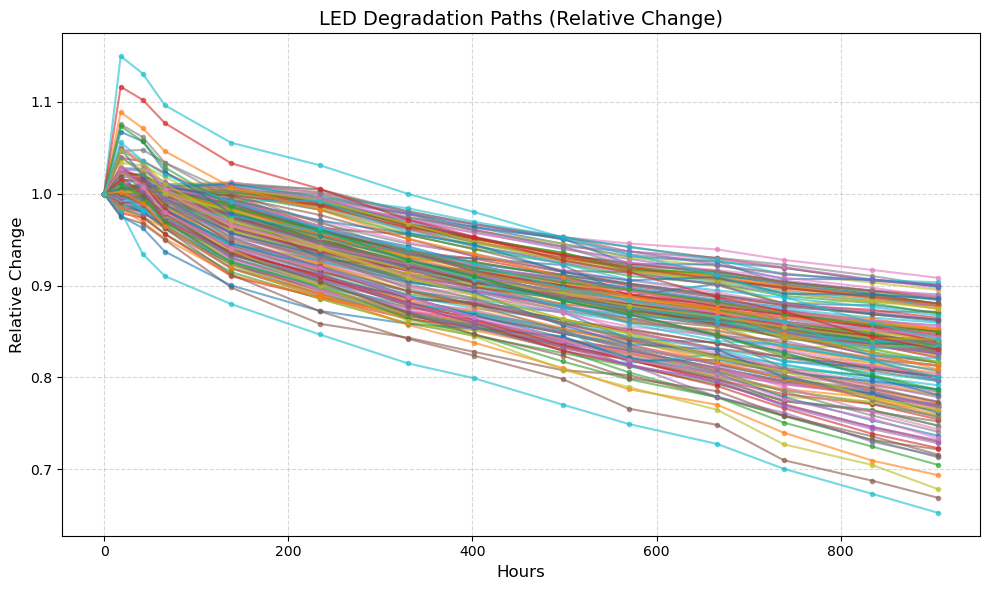

正在处理: GaAsLaser.csv...


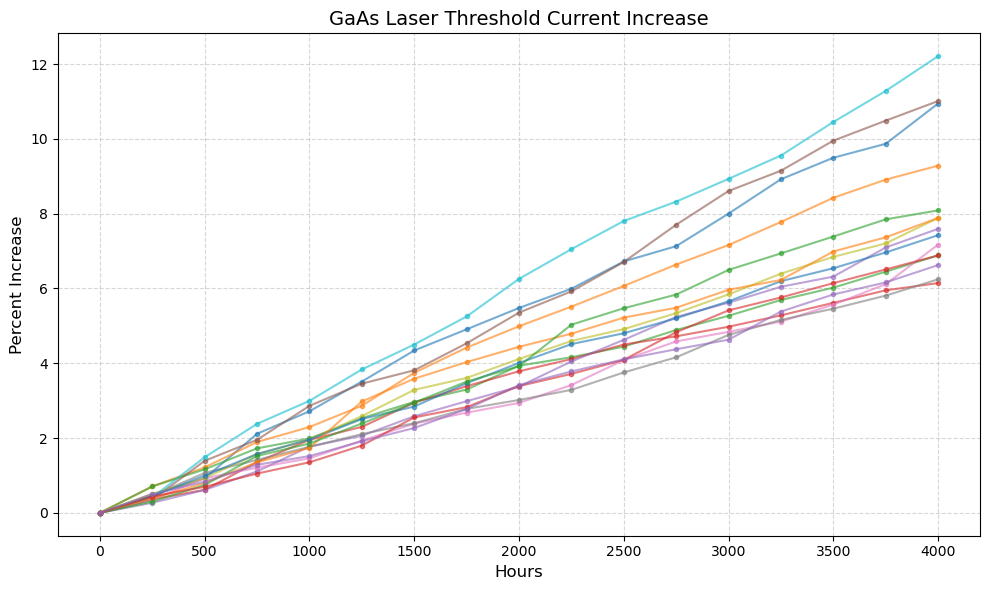

正在处理: DiskBer.csv...


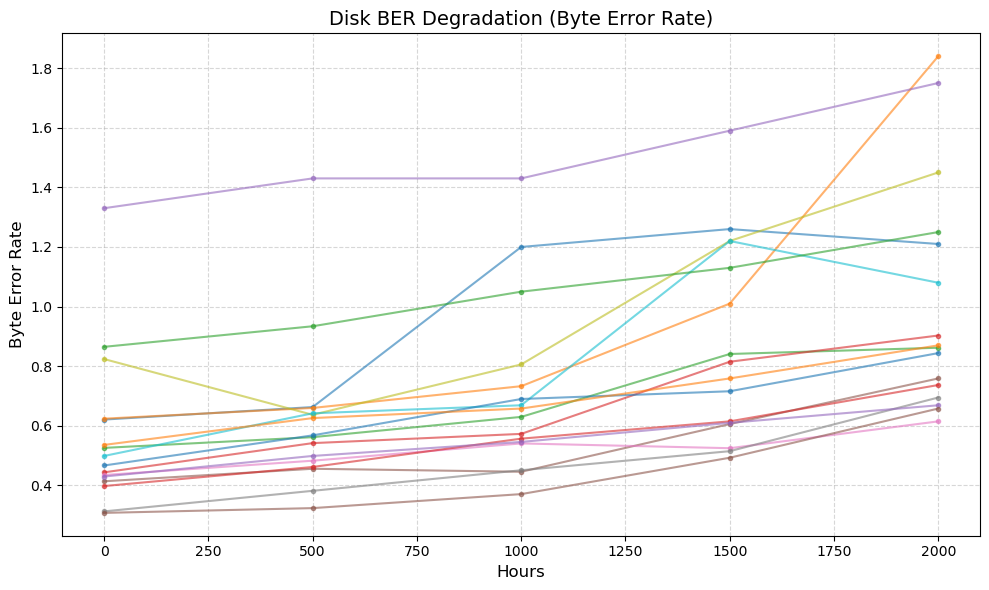

正在处理: MetalWear.csv...


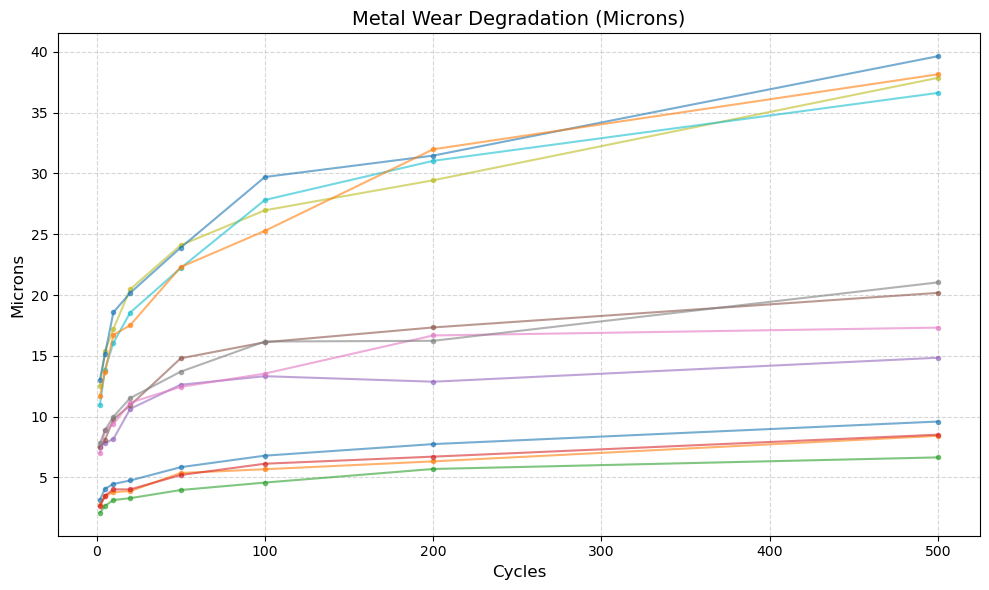

正在处理: Resistor.csv...


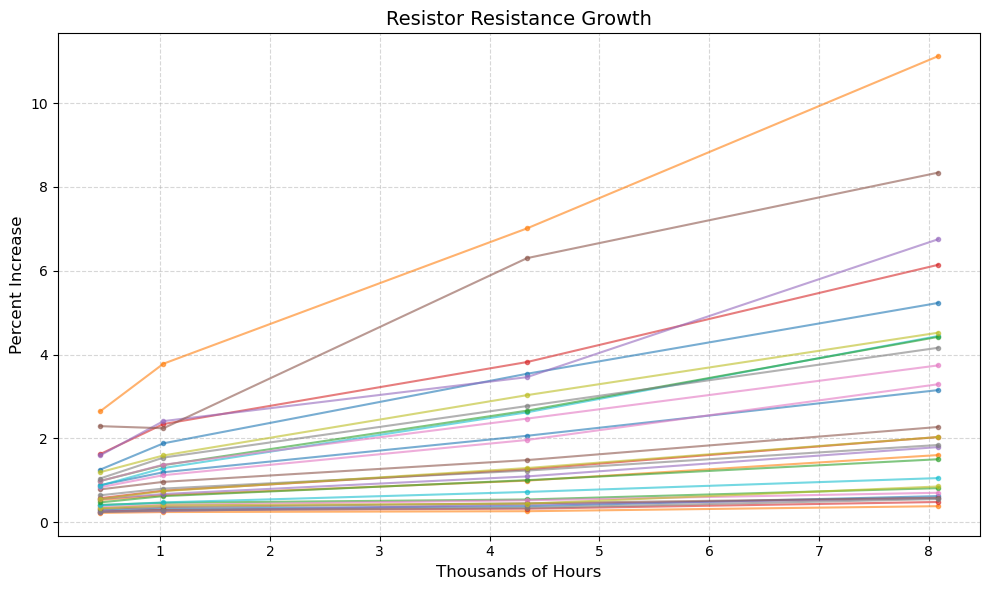

正在处理: AlloyA.csv...


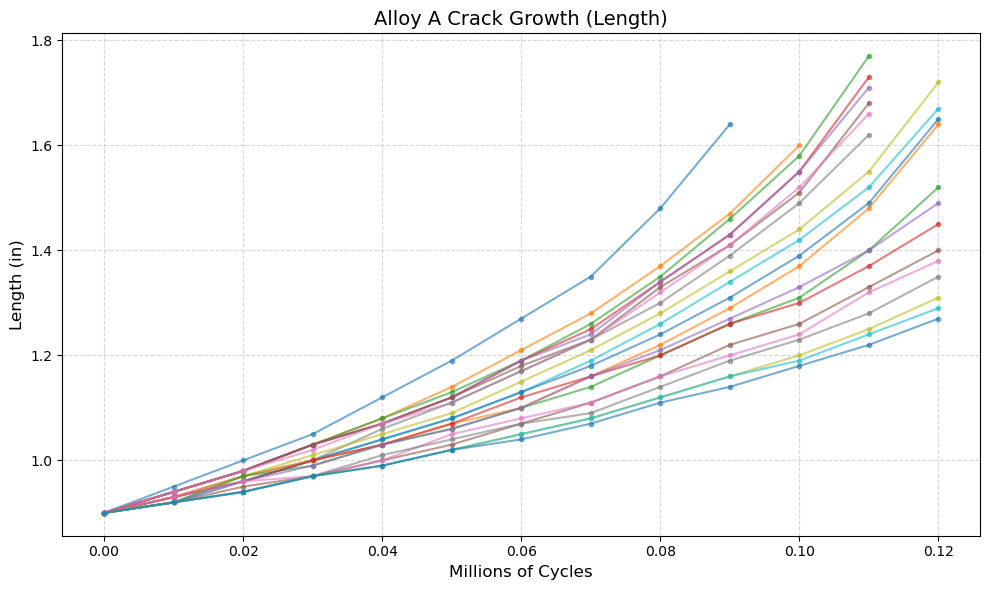

正在处理: DeviceB.csv...


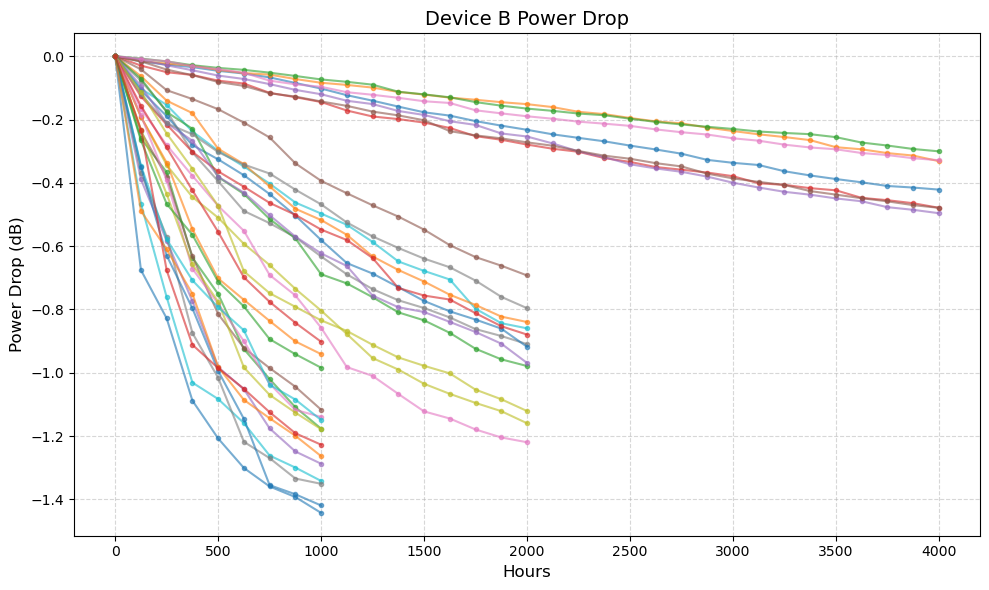

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plot_configs = [
    {
        'file': 'LED-Azerostart.csv',
        'x': 'Hours',
        'y': 'Relative Change',
        'group': 'Unit Number',
        'title': 'LED Degradation Paths (Relative Change)'
    },
    {
        'file': 'GaAsLaser.csv',
        'x': 'Hours',
        'y': 'Percent Increase',
        'group': 'Unit Number',
        'title': 'GaAs Laser Threshold Current Increase'
    },
    {
        'file': 'DiskBer.csv',
        'x': 'Hours',
        'y': 'Byte Error Rate',
        'group': 'Disk Number',
        'title': 'Disk BER Degradation (Byte Error Rate)'
    },
    {
        'file': 'MetalWear.csv',
        'x': 'Cycles',
        'y': 'Microns',
        'group': 'Unit Number',
        'title': 'Metal Wear Degradation (Microns)'
    },
    {
        'file': 'Resistor.csv',
        'x': 'Thousands of Hours',
        'y': 'Percent Increase',
        'group': 'Resistor ID',
        'title': 'Resistor Resistance Growth'
    },
    {
        'file': 'AlloyA.csv',
        'x': 'Millions of Cycles',
        'y': 'Length (in)',
        'group': 'Specimen Number',
        'title': 'Alloy A Crack Growth (Length)'
    },
    {
        'file': 'DeviceB.csv',
        'x': 'Hours',
        'y': 'Power Drop (dB)',
        'group': 'Device Number',
        'title': 'Device B Power Drop'
    }
]

def plot_all_degradation(configs):
    for cfg in configs:
        file_name = cfg['file']
        if not os.path.exists(file_name):
            print(f"找不到文件: {file_name}")
            continue
            
        print(f"正在处理: {file_name}...")
        df = pd.read_csv(file_name)
        
        plt.figure(figsize=(10, 6))

        units = df[cfg['group']].unique()

        for unit in units:
            unit_data = df[df[cfg['group']] == unit]
            unit_data = unit_data.sort_values(by=cfg['x'])
            
            plt.plot(unit_data[cfg['x']], unit_data[cfg['y']], 
                     marker='o', markersize=3, alpha=0.6, 
                     label=f'Unit {unit}' if len(units) <= 10 else "")
        
        plt.xlabel(cfg['x'], fontsize=12)
        plt.ylabel(cfg['y'], fontsize=12)
        plt.title(cfg['title'], fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.5)
        
        if 0 < len(units) <= 10:
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            
        plt.tight_layout()
        plt.show()

plot_all_degradation(plot_configs)